In [1]:
! pip install -e .

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Obtaining file:///home/f73aeabd-6de4-471d-92a9-1ba552ae6153/Quantum_Master_Equation
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for quantum-master-equation (pyproject.toml) ... done
  Created wheel for quantum-master-equation: filename=quantum_master_equation-0.1.0-0.editable-py3-none-any.whl size=1799 sha256=3b44e6b4cb38f85772e4b00f79568722e5cacbcccf0a624052f52156b583a805
  Stored in directory: /tmp/pip-ephem-wheel-cache-yv_mgqox/wheels/09/00/12/b285b3f033cfebec163d4b77a97557519b34db7913f1b7bec4
Successfully built quantum-master-equation
  Attempting uninstall: quantum-master-equation
    Found existing installation: quantum-master-equation 0.1.0
    Uninstalling quantum-master-equation-0

In [4]:
import numpy as np
import qme 

# Open Systems – Quantum Master Equation

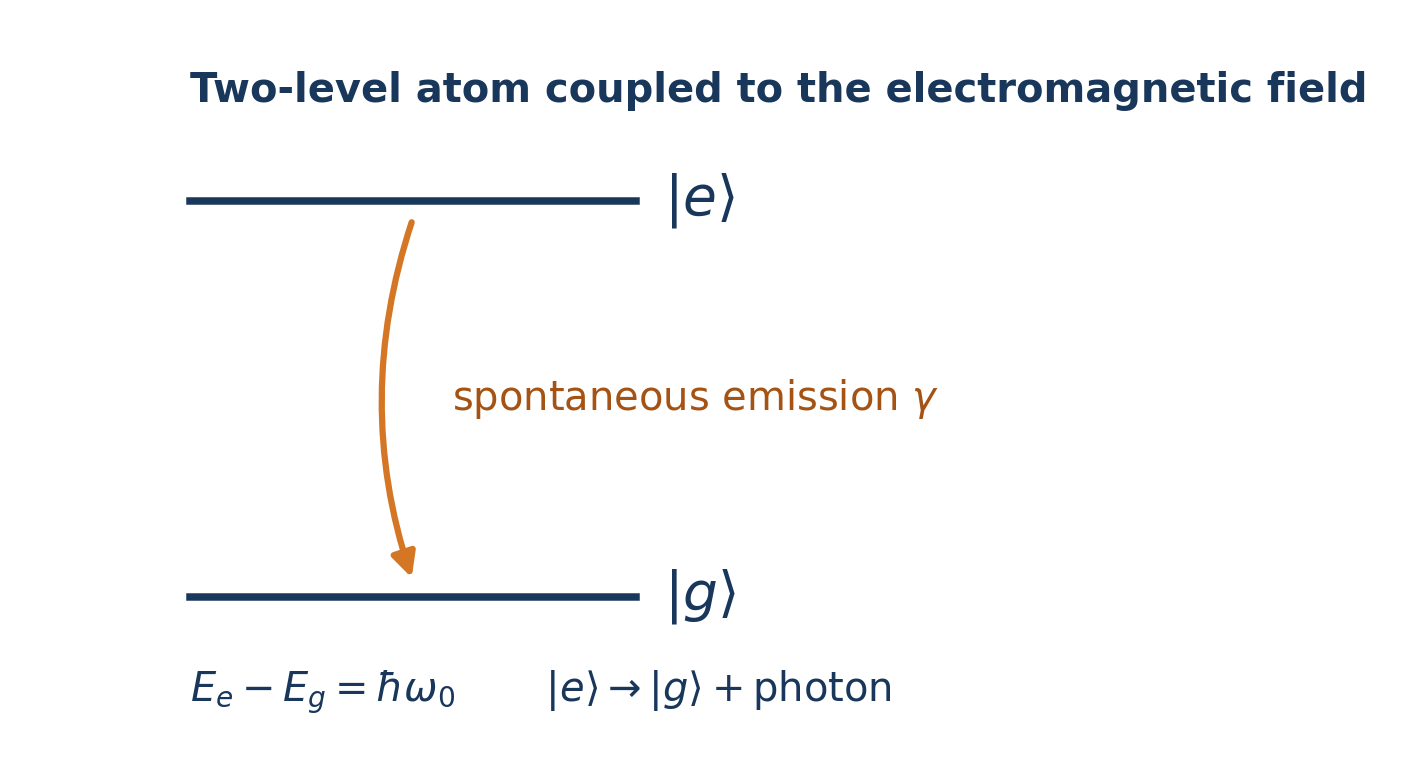

The atom is prepared in the upper, excited state $|e\rangle$ at $t=0$.

Physically, we expect an atom prepared in the excited state $|e\rangle$
to eventually decay to the ground state $|g\rangle$, emitting a photon.

The excited state has a finite lifetime, which gives the transition a
finite natural linewidth.

This happens because the atom is not isolated: it is coupled to an
environment, such as the electromagnetic field and its vacuum modes.

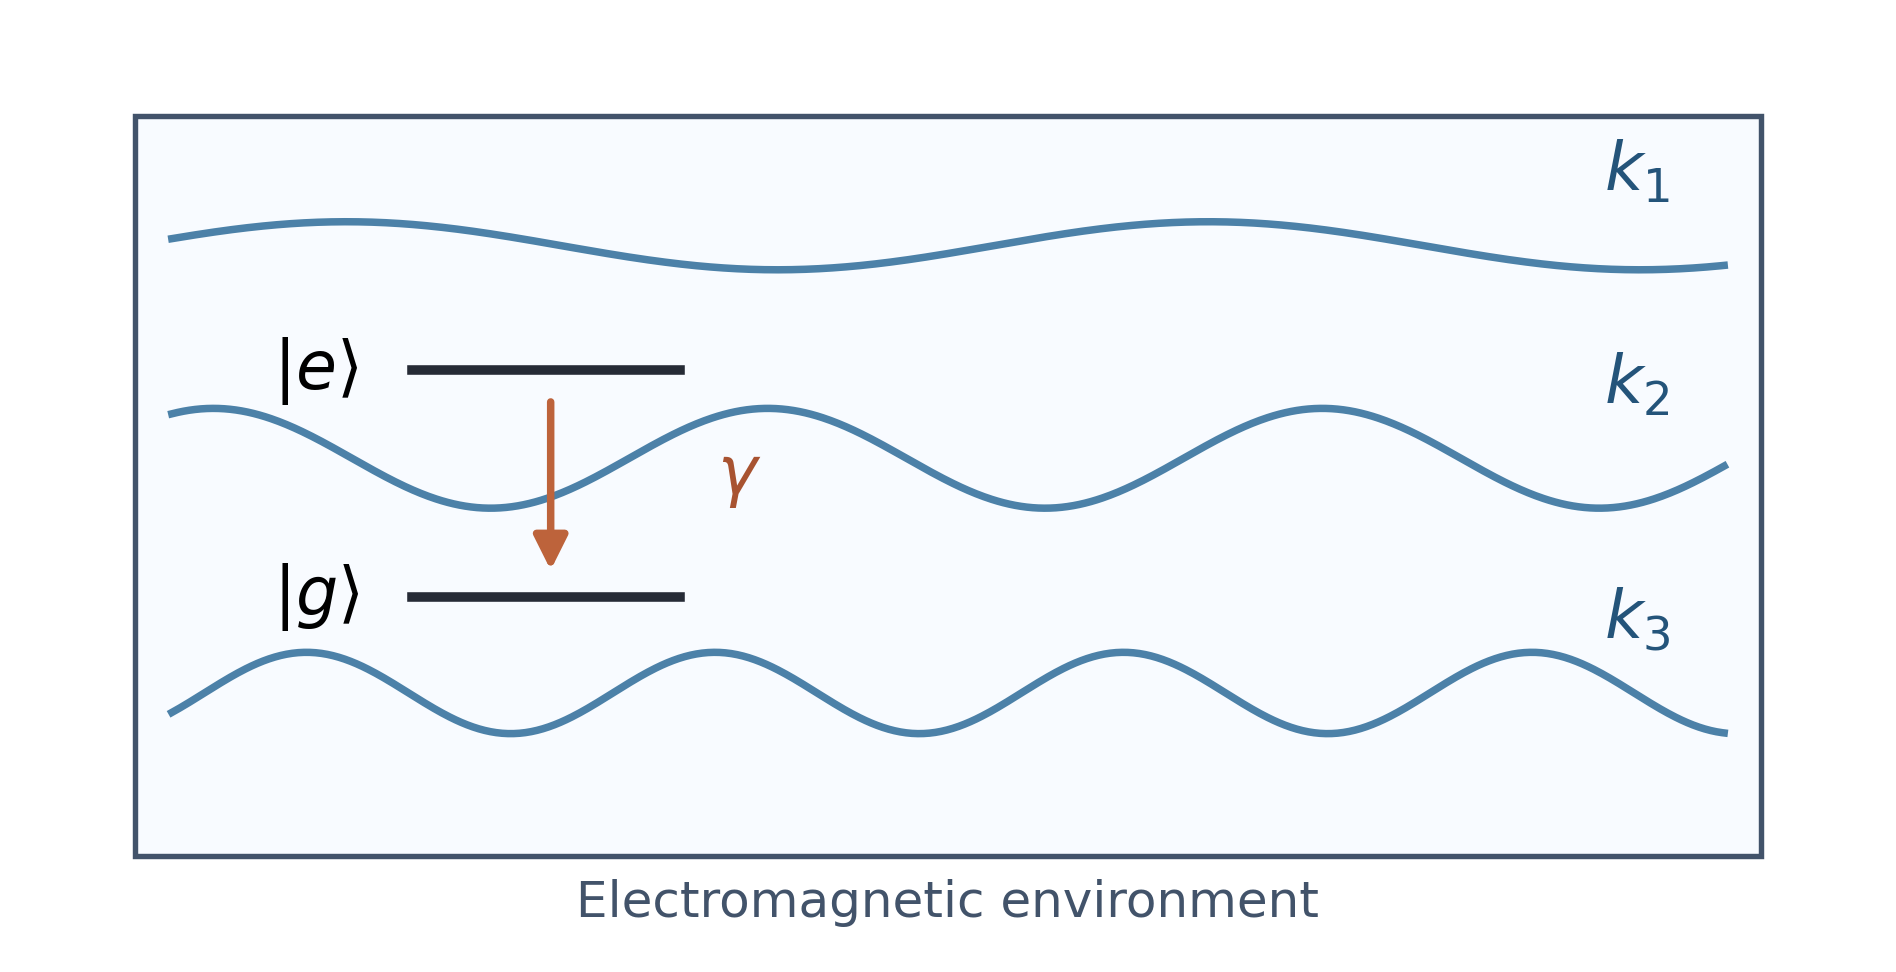

To describe the decay $|e\rangle \rightarrow |g\rangle$, we need to include the environment—the electromagnetic field.

We could consider the combined system of atom and environment, $S+E$. For example, photon emission changes the joint state as

$$
|e\rangle\otimes|0\rangle_E
\;\longrightarrow\;
|g\rangle\otimes|1\rangle_E,
$$

where $|0\rangle_E$ is the field vacuum and $|1\rangle_E$ represents an emitted photon.

Describing the full system is complicated because the environment has many degrees of freedom. We therefore seek an equation for the atom alone.

**Goal:** 

Derive a description of the system's dynamics that accounts for dissipative effects caused by coupling to the environment, without explicitly tracking the environment's dynamics.

We seek a dynamical map $\mathcal{E}_t$ such that

$$
\rho_S(0) \longmapsto \rho_S(t)
= \mathcal{E}_t\!\left[\rho_S(0)\right].
$$

Here, $\rho_S$ is the system's reduced density matrix. The map
$\mathcal{E}_t$ describes its evolution while accounting for the
environment's effects.

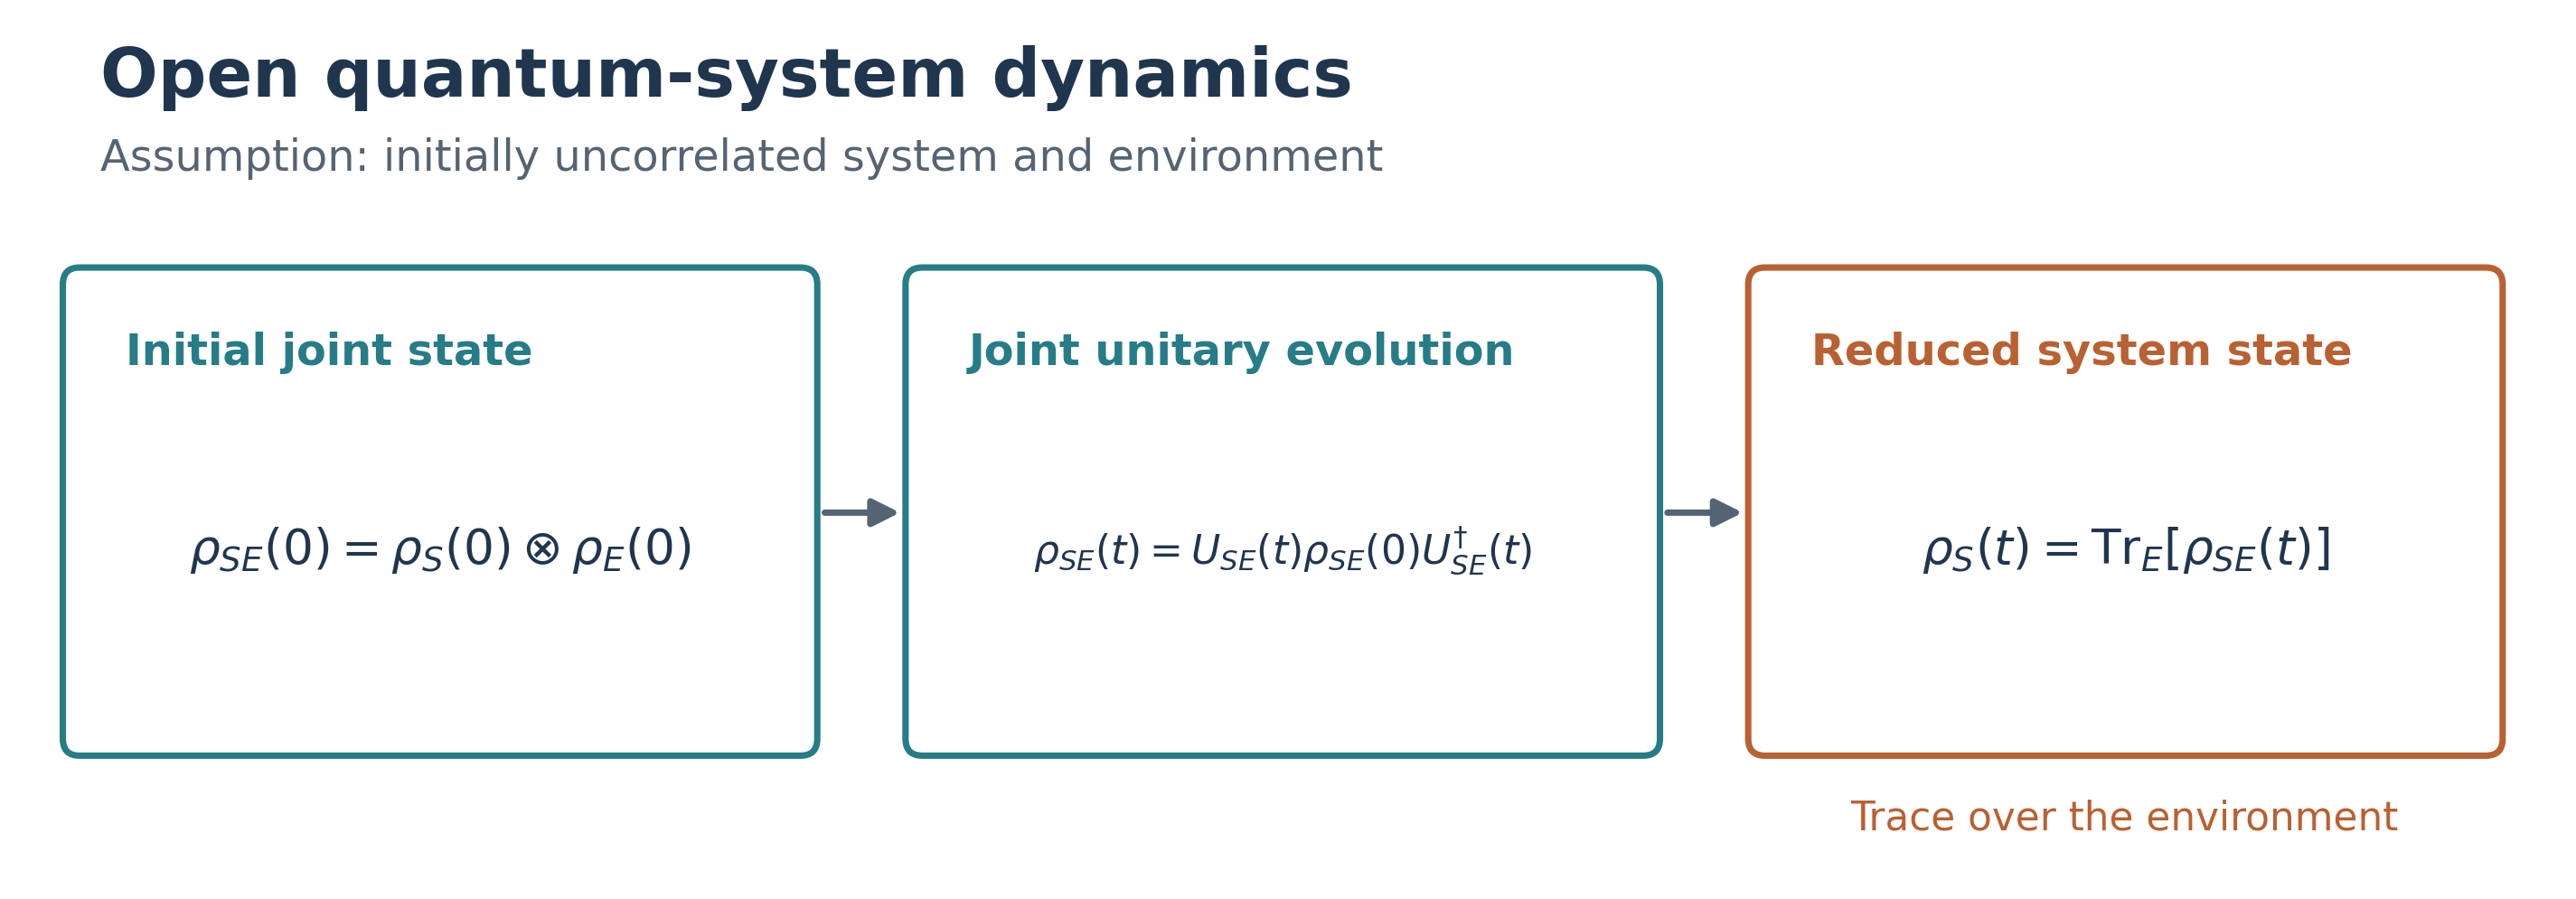

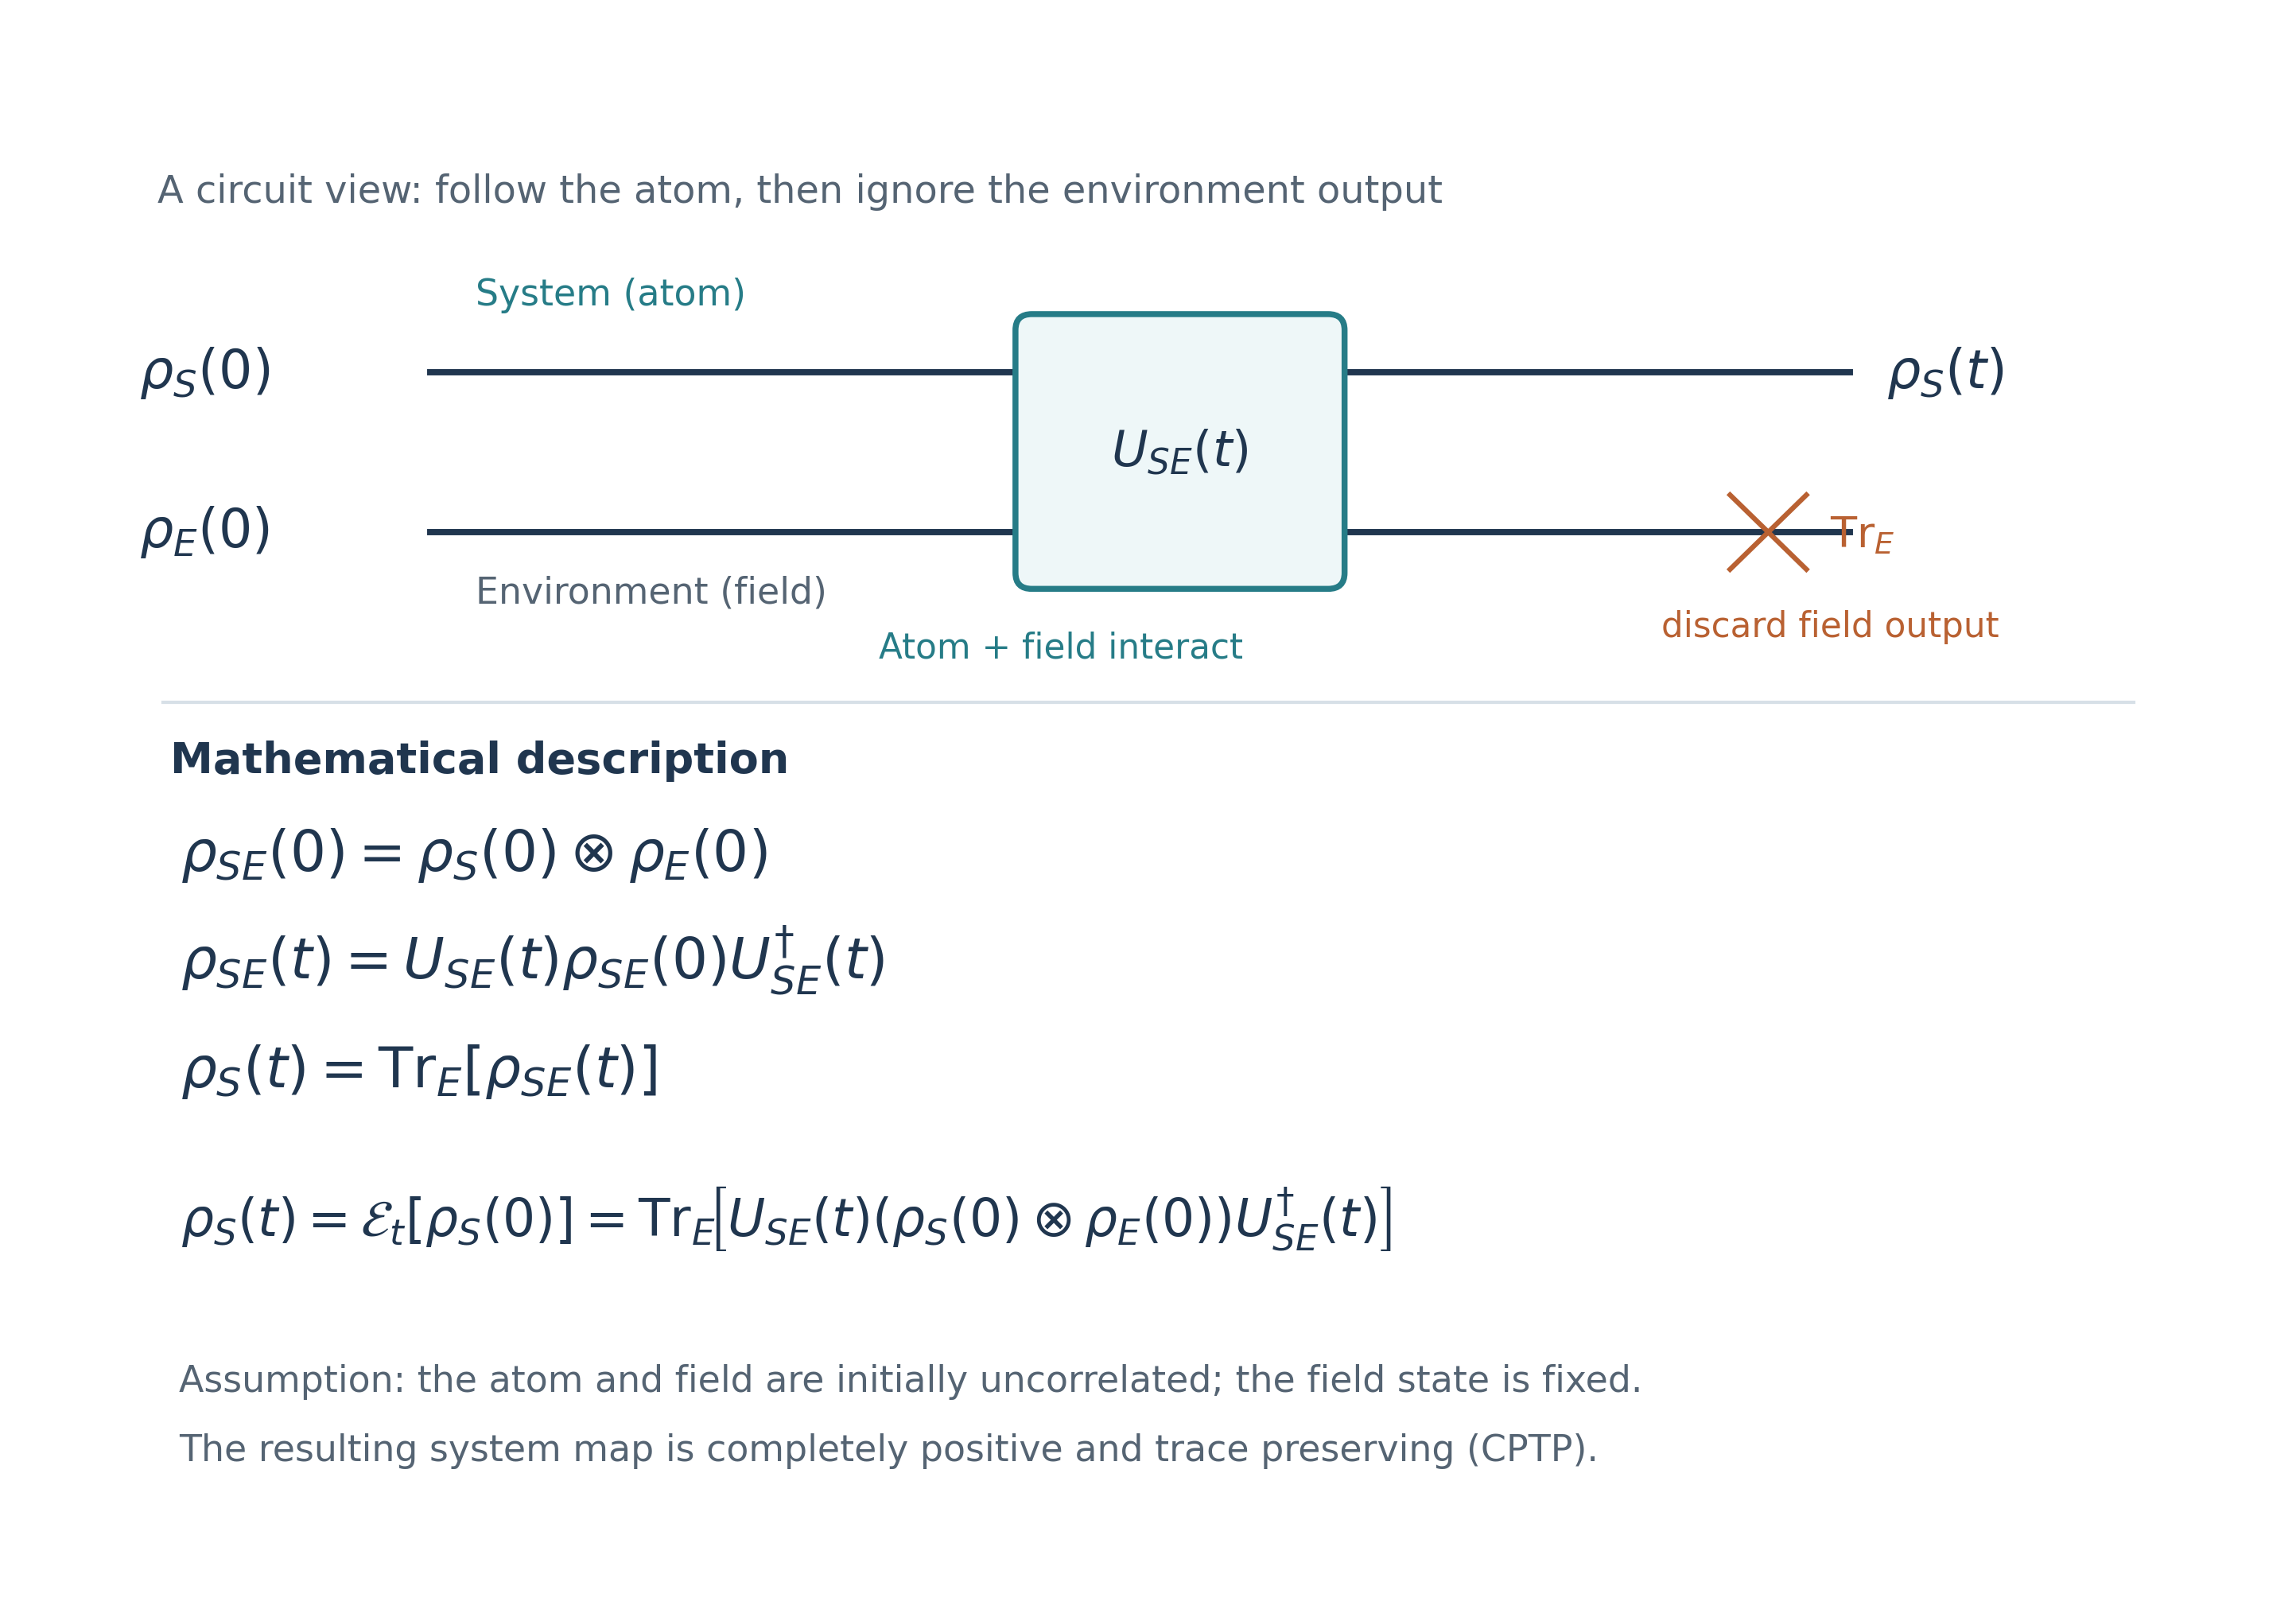

### From joint evolution to an open-system map

The atom ($S$) and electromagnetic field ($E$) begin in an uncorrelated state,
$\rho_{SE}(0)=\rho_S(0)\otimes\rho_E(0)$. They interact through the joint
unitary operator $U_{SE}(t)$. We then trace over the field to obtain the
atom's reduced state:

$$
\rho_S(t)=\operatorname{Tr}_E\!\left[
U_{SE}(t)\bigl(\rho_S(0)\otimes\rho_E(0)\bigr)
U_{SE}^{\dagger}(t)
\right].
$$

Thus, the atom can show irreversible-looking decay even though the combined
atom–field system evolves unitarily.

### Physical requirements for the dynamical map

The system state $\rho_S(t)$ must remain a valid density matrix:

- **Hermiticity:** $\rho_S(t)^\dagger=\rho_S(t)$.
- **Positivity:** $\rho_S(t)\geq 0$.
- **Unit trace:** $\operatorname{Tr}[\rho_S(t)]=1$.

The map $\mathcal{E}_t$ is therefore required to be **completely positive
and trace preserving (CPTP)**. Complete positivity also guarantees that
the map remains physical when the system is entangled with an additional,
unaffected system.

## Complete positivity and trace preservation

A quantum map $\mathcal E$ is **completely positive (CP)** if it preserves
positivity even when the system $S$ is part of a larger system $SA$:

$$
X_{SA}\geq 0
\quad\Longrightarrow\quad
(\mathcal E\otimes I_A)(X_{SA})\geq 0
$$

for **any** additional system $A$. The system $A$ may be entangled with $S$.
Here, $I_A$ means that no map is applied to $A$, and $X\geq0$ means that
$X$ has no negative eigenvalues.

### Why Kraus operators prove CP

Suppose the map has a Kraus representation

$$
\mathcal E(\rho)=\sum_k K_k\rho K_k^\dagger.
$$

For any positive joint operator $X_{SA}$,

$$
(\mathcal E\otimes I_A)(X_{SA})
=
\sum_k(K_k\otimes I_A)X_{SA}(K_k^\dagger\otimes I_A).
$$

Let $|v\rangle$ be any vector and define
$|w_k\rangle=(K_k^\dagger\otimes I_A)|v\rangle$. Then

$$
\langle v|(\mathcal E\otimes I_A)(X_{SA})|v\rangle
=
\sum_k\langle w_k|X_{SA}|w_k\rangle
\geq 0.
$$

Each term is nonnegative because $X_{SA}\geq0$. Thus the output remains
positive even when $S$ is entangled with $A$: the map is **CP**.

The map is **trace preserving (TP)** when

$$
\boxed{\sum_k K_k^\dagger K_k=I_S.}
$$

### Example 1: Orientation toward $|0\rangle$

Consider the map from the lecture notes:

$$
\boxed{
\mathcal E_\epsilon(\rho)
=
(1-\epsilon)\rho+
\epsilon\,\operatorname{Tr}(\rho)|0\rangle\langle0|,
\qquad 0\leq\epsilon\leq1.
}
$$

For a density matrix, $\operatorname{Tr}(\rho)=1$. The trace factor in the
general formula makes the map linear for arbitrary input operators.

Writing

$$
\rho=
\begin{pmatrix}
a&c\\
c^*&b
\end{pmatrix},
\qquad a+b=1,
$$

gives

$$
\mathcal E_\epsilon(\rho)=
\begin{pmatrix}
a+\epsilon b&(1-\epsilon)c\\
(1-\epsilon)c^*&(1-\epsilon)b
\end{pmatrix}.
$$

One set of Kraus operators is

$$
K_0=\sqrt{1-\epsilon}\,I,\qquad
K_1=\sqrt{\epsilon}\,|0\rangle\langle0|,\qquad
K_2=\sqrt{\epsilon}\,|0\rangle\langle1|.
$$

They satisfy

$$
\begin{aligned}
\sum_{k=0}^{2}K_k^\dagger K_k
&=(1-\epsilon)I+
\epsilon|0\rangle\langle0|+
\epsilon|1\rangle\langle1|\\
&=I.
\end{aligned}
$$

Therefore, the map is **trace preserving**. Their Kraus form also proves
that it is **completely positive**.

### Example 2: Decay of the excited atom

For the atom, identify $|g\rangle=|0\rangle$ and $|e\rangle=|1\rangle$.
A decay channel with probability $0\leq p\leq1$ has Kraus operators

$$
L_0=|g\rangle\langle g|
+\sqrt{1-p}\,|e\rangle\langle e|,
\qquad
L_1=\sqrt p\,|g\rangle\langle e|.
$$

They obey

$$
L_0^\dagger L_0+L_1^\dagger L_1=I.
$$

Hence the decay channel is **CPTP**. For an atom initially in $|e\rangle$,

$$
\boxed{
\mathcal D_p(|e\rangle\langle e|)
=
(1-p)|e\rangle\langle e|
+p|g\rangle\langle g|.
}
$$

The excited-state probability becomes $1-p$, while the ground-state
probability becomes $p$. Their sum remains one.

**Note:** The orientation map and the decay channel are different maps.
For a state with coherence, the orientation map multiplies its off-diagonal
elements by $1-\epsilon$; the decay channel multiplies them by
$\sqrt{1-p}$.

In [7]:
I = np.eye(2, dtype=complex)
g = np.array([[1.0], [0.0]], dtype=complex)
e = np.array([[0.0], [1.0]], dtype=complex)

Pg = g @ g.conj().T
Pe = e @ e.conj().T

# Example A: orientation/reset map
epsilon = 0.3
reset_kraus = [
    np.sqrt(1 - epsilon) * I,
    np.sqrt(epsilon) * Pg,
    np.sqrt(epsilon) * (g @ e.conj().T),
]

reset_channel = lambda rho: qme.utils.apply_kraus(rho, reset_kraus)
reset_output = reset_channel(Pe)

print("RESET MAP: input |e><e|")
print("Output:\n", reset_output)
print("TP:", qme.utils.trace_preserving(reset_kraus))
print("CP:", qme.utils.completely_positive(reset_channel, d=2))
print("Hermitian:", qme.utils.hermiticity(Pe, reset_channel))

expected = (1 - epsilon) * Pe + epsilon * Pg
print("Matches formula:", np.allclose(reset_output, expected))

RESET MAP: input |e><e|
Output:
 [[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]
TP: True
CP: True
Hermitian: True
Matches formula: True


In [8]:
# Example B: spontaneous decay
p = 0.3
decay_kraus = [Pg + np.sqrt(1 - p) * Pe, np.sqrt(p) * (g @ e.conj().T),]
decay_channel = lambda rho: qme.utils.apply_kraus(rho, decay_kraus)
decay_output = decay_channel(Pe)

print("\nDECAY CHANNEL: input |e><e|")
print("Output:\n", decay_output)
print("TP:", qme.utils.trace_preserving(decay_kraus))
print("CP:", qme.utils.completely_positive(decay_channel, d=2))
print("Hermitian:", qme.utils.hermiticity(Pe, decay_channel))


# Apply decay to half of an entangled two-qubit state
bell = (np.kron(g, g) + np.kron(e, e)) / np.sqrt(2)
rho_bell = bell @ bell.conj().T
joint_output = sum(np.kron(K, I) @ rho_bell @ np.kron(K.conj().T, I) for K in decay_kraus)

print("\nDECAY ACTING ON HALF OF AN ENTANGLED STATE")
print("Joint-output eigenvalues:", np.linalg.eigvalsh(joint_output).round(6))
print("Joint-output trace:", np.trace(joint_output).real)


DECAY CHANNEL: input |e><e|
Output:
 [[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]
TP: True
CP: True
Hermitian: True

DECAY ACTING ON HALF OF AN ENTANGLED STATE
Joint-output eigenvalues: [0.   0.   0.15 0.85]
Joint-output trace: 0.9999999999999998


### Complete positivity

A quantum map $\mathcal E$ is **completely positive (CP)** if it preserves
positivity even when it acts on only one part of an entangled system.

For any additional system $A$ and any positive joint state $\rho_{SA}$,

$$
\rho_{SA}\geq 0
\quad\Longrightarrow\quad
(\mathcal E\otimes I_A)(\rho_{SA})\geq 0.
$$

Here, $I_A$ means that nothing is done to system $A$.

**Why is ordinary positivity insufficient?** Ordinary positivity checks
the state of $S$ alone. If $S$ is entangled with $A$, a map that is only
positive might produce a joint matrix with a negative eigenvalue. Such a
matrix is not a valid quantum state.

**How can we show CP?** A Kraus representation guarantees it:

$$
\mathcal E(\rho)=\sum_k K_k\rho K_k^\dagger.
$$

If, in addition,

$$
\sum_k K_k^\dagger K_k=I,
$$

the map is also **trace preserving**. It is then a **CPTP map**.

> **One-sentence oral answer:** Complete positivity means that a quantum
> operation remains physically valid when applied to part of a larger,
> possibly entangled system.

| Valid density matrix $\rho$ | Physical quantum map $\mathcal E$ |
|---|---|
| Hermitian: $\rho^\dagger=\rho$ | Preserves Hermiticity |
| Unit trace: $\operatorname{Tr}(\rho)=1$ | Trace preserving (TP) |
| Positive semidefinite: $\rho\geq0$ | Completely positive (CP) |

**In Short:** 

A density matrix must be Hermitian, positive semidefinite, and have trace one. 
In an open system, its evolution is described by a **CPTP map**, which preserves valid quantum states even when the system is entangled with an additional system.

**Note:**

CP already guarantees Hermiticity preservation. 
That is why we usually call the map *CPTP* rather than listing Hermiticity preservation separately.